# Importing Libraries

In [1]:
# Standard Library & Utilities
import json

# Core Data Manipulation
import pandas as pd

# Machine Learning & Preprocessing
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Data Visualization
import matplotlib.pyplot as plt

# Geospatial Analysis
import geopandas as gpd
from keplergl import KeplerGl


# Loading DF

In [2]:
norm_df = pd.read_csv('..\\Data\\NMF_STREET.csv', low_memory=False)
nyc_map = gpd.read_file("..\\Data\\Modified Zip Code Tabulation Areas (MODZCTA).geojson")
streets_projected = gpd.read_file("..\\Data\\nyc_clustered_streets.gpkg")

# Clustering KMEANS

In [3]:
# Print clustering output
def output(labels):
    labels = pd.Series(labels)
    print("The labels:\n", labels)
    print("===================")
    print("Cluster Counts:\n", labels.value_counts())


In [4]:
# Drop incident zip column
Features = norm_df.drop("Street_Name", axis=1)

## WCSS graph

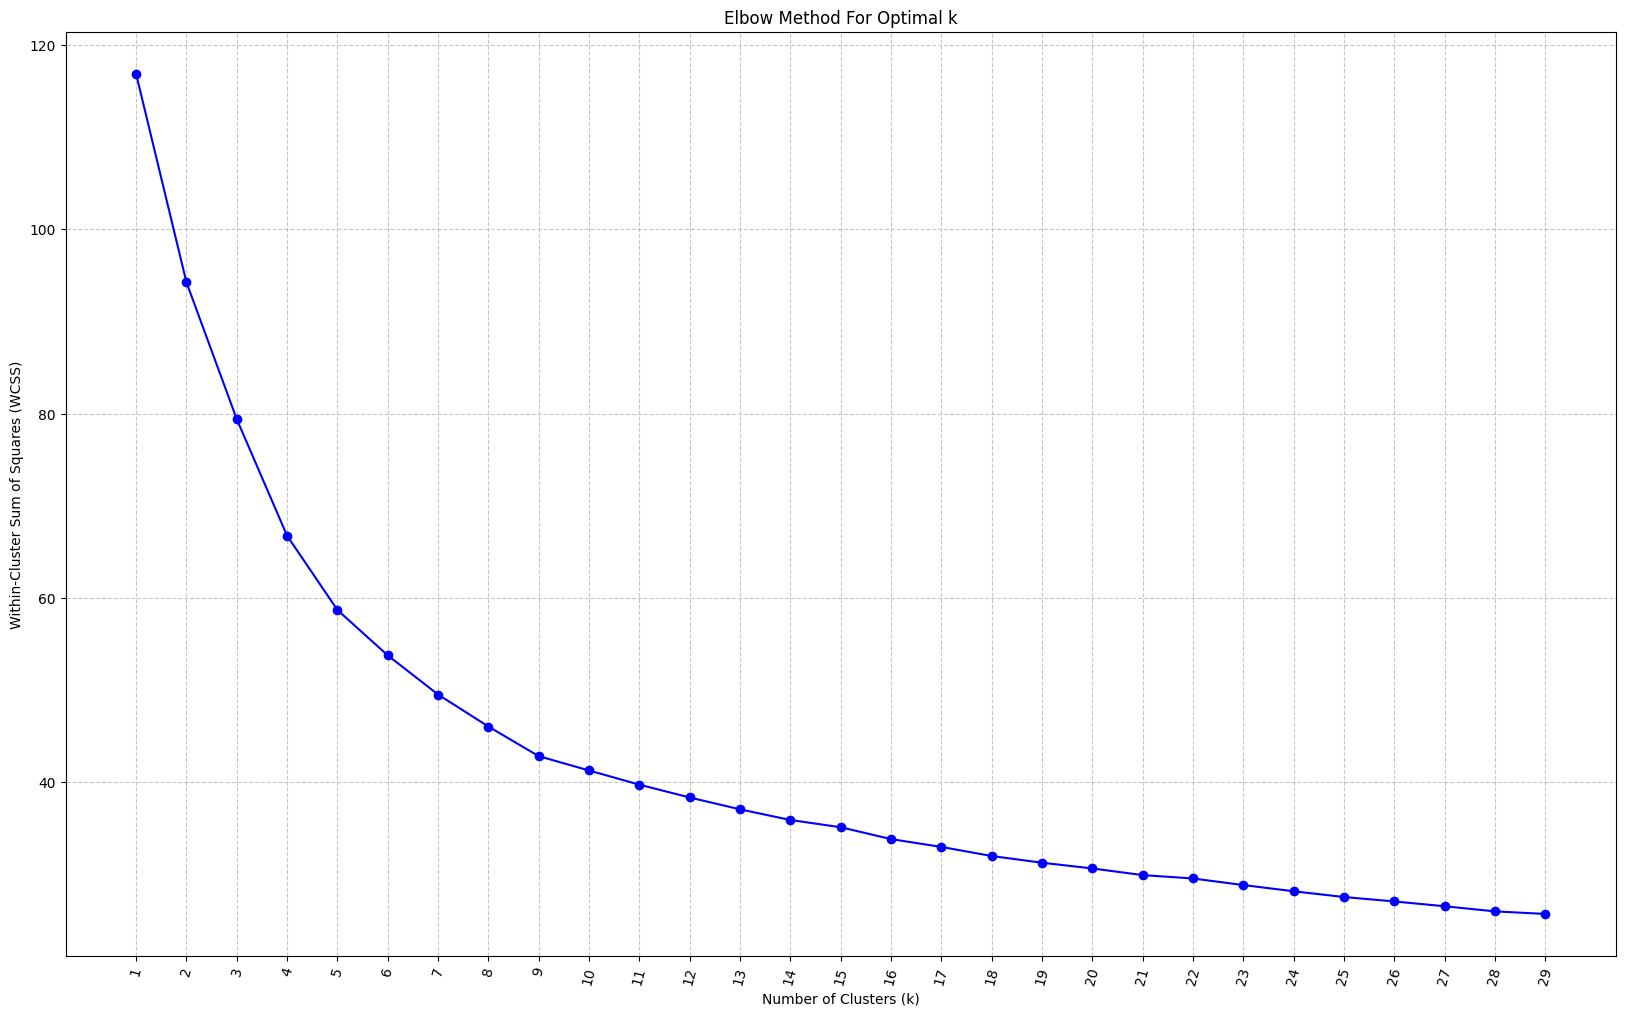

In [5]:
# Calculate WCSS ( Within-Cluster Sum of Squares ) for different values of k
wcss = []
k_range = range(1, 30) # Testing k=1 through k=100 

for k in k_range:
    # random_state ensures reproducible results
    # n_init=10 suppresses future warnings in scikit-learn
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(Features)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(20, 12))
plt.plot(k_range, wcss, marker='o', linestyle='-', color='b')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')

# Rotate the x-axis labels by 45 degrees
plt.xticks(k_range, rotation=75) 

plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Silhouette Score

In [6]:
score_lst = []
k_range = range(5, 30) # Define the range once to keep it consistent

for k in k_range:
    # Get labels
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto").fit(Features)
    labels = pd.Series(kmeans.labels_)
    norm_df["Cluster"] = labels

    # Calculate the Silhouette Score
    score = silhouette_score(Features, labels)
    score_lst.append(score)

# Create the x-axis list (number of clusters)
k_lst = list(k_range)    

# --- Make the plot ---
plt.figure(figsize=(10, 6)) # Set the figure size
plt.plot(k_lst, score_lst, marker='o', linestyle='-', color='b') # Added points 'o' for visibility

# Add labels and title
plt.title('Silhouette Score vs. Number of Clusters (k)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')

# Formatting to make it look nice
plt.xticks(k_lst) # Shows every 'k' value on the x-axis
plt.grid(True, linestyle='--', alpha=0.7) # Adds a subtle grid

# Display the plot
plt.show()

KeyboardInterrupt: 

## Kmeans for 9 clusters

In [ ]:
kmeans = KMeans(n_clusters = 9,random_state = 42, n_init="auto").fit(Features)
labels = pd.Series(kmeans.labels_)
norm_df["Cluster"] = labels
output(labels)

The labels:
 0       2
1       3
2       6
3       5
4       5
       ..
8064    2
8065    2
8066    3
8067    5
8068    5
Length: 8069, dtype: int32
Cluster Counts:
 5    2561
6    1534
2    1529
0     610
1     439
4     430
8     343
3     322
7     301
Name: count, dtype: int64


In [ ]:
# Check how many streets are in each of the 9 clusters
val_count_sorted = norm_df['Cluster'].value_counts().sort_index()
val_count_sorted

Cluster
0     610
1     439
2    1529
3     322
4     430
5    2561
6    1534
7     301
8     343
Name: count, dtype: int64

In [ ]:
# Define the outlier clusters we want to push to the end
outlier_clusters = singleton_labels = val_count_sorted[val_count_sorted == 1].index.tolist()

# Get a list of all current clusters in the dataframe, sorted numerically
current_clusters = sorted(norm_df['Cluster'].dropna().unique())

# Separate the "main" clusters from the "outlier" clusters
main_clusters = [c for c in current_clusters if c not in outlier_clusters]
outliers_present = [c for c in outlier_clusters if c in current_clusters]

# Create a new ordered list: Main clusters first, followed by outliers at the end
new_cluster_order = main_clusters + outliers_present

# Create a mapping dictionary {old_id: new_id}
# This automatically assigns 0, 1, 2... etc.
# The main clusters will become 0 to 10, and the outliers will become 11, 12, 13, 14.
cluster_mapping = {old_id: new_id for new_id, old_id in enumerate(new_cluster_order)}

# Let's print the mapping so we can verify it worked as intended
print("Here is how the clusters are being renumbered:")
for old, new in cluster_mapping.items():
    print(f"Old Cluster {old} --> New Cluster {new}")

# Apply the mapping to overwrite the old numbers
norm_df['Cluster'] = norm_df['Cluster'].map(cluster_mapping)

Here is how the clusters are being renumbered:
Old Cluster 0 --> New Cluster 0
Old Cluster 1 --> New Cluster 1
Old Cluster 2 --> New Cluster 2
Old Cluster 3 --> New Cluster 3
Old Cluster 4 --> New Cluster 4
Old Cluster 5 --> New Cluster 5
Old Cluster 6 --> New Cluster 6
Old Cluster 7 --> New Cluster 7
Old Cluster 8 --> New Cluster 8


In [ ]:
# Df after clustering
norm_df

,Street_Name,Profile_1 (Street_and_Transportation_Pct),Profile_2 (Noise_Pct),Profile_3 (Other/Misc_LType_Pct),Profile_4 (Sanitation_and_Trash_Pct),Profile_5 (Street_and_Infrastructure_Pct),Profile_6 (Residential_and_Mixed_Use_Pct),Profile_7 (Weekend_Ratio),Profile_8 (Street_and_Transportation_Pct),Profile_9 (Night_Complaint_Pct),Cluster
0,1 AVENUE,0.005946,0.020687,0.021268,0.014211,0.009879,0.074052,0.053805,0.075419,0.053882,2
1,1 AVENUE LOOP,0.000000,0.000404,0.058312,0.000000,0.224141,0.000000,0.041367,0.000000,0.000003,3
2,1 COURT,0.018913,0.000387,0.025603,0.039217,0.027215,0.017071,0.063476,0.062112,0.000000,6
3,1 PLACE,0.026487,0.008806,0.023333,0.009426,0.023842,0.024168,0.051735,0.032822,0.025281,5
4,1 STREET,0.016935,0.017511,0.023842,0.018589,0.023915,0.037923,0.047534,0.046725,0.039409,5
...,...,...,...,...,...,...,...,...,...,...,...
8064,ZOE STREET,0.007555,0.007624,0.058871,0.023651,0.000000,0.105265,0.071358,0.037726,0.040112,2
8065,ZOLLER ROAD,0.000380,0.039904,0.081958,0.032889,0.010412,0.045078,0.068352,0.000000,0.087117,2
8066,ZOO BRIDGE,0.000000,0.000028,0.034204,0.000000,0.259806,0.000000,0.000000,0.000000,0.000000,3
8067,ZULETTE AVENUE,0.025805,0.003964,0.020691,0.021688,0.035939,0.007518,0.063647,0.042038,0.030582,5


In [ ]:
# Street data with geo info
streets_projected

,full_street_name,geometry
0,AVENUE NORTH,"POLYGON ((994139.216 163416.286, 994143.124 16..."
1,HONE AVENUE,"POLYGON ((1023559.637 254630.271, 1023559.909 ..."
2,48 STREET,"POLYGON ((1011219.591 219044.016, 1011216.783 ..."
3,LAIGHT STREET,"POLYGON ((981020.607 202397.126, 981016.746 20..."
4,BROOK AVENUE,"POLYGON ((950481.675 142652.323, 950465.007 14..."
...,...,...
122255,CLOVE LAKE PATH,"POLYGON ((954037.12 164385.811, 954026.004 164..."
122256,ALLEY,"POLYGON ((1014506.033 175164.65, 1014378.255 1..."
122257,64 AV PEDESTRIAN OPAS,"POLYGON ((1027497.702 206882.915, 1027501.503 ..."
122258,ALLEY,"POLYGON ((1024699.173 202136.356, 1024647.443 ..."


In [ ]:
# Extract the centroids from the fitted model
centroids = kmeans.cluster_centers_

# Convert to a DataFrame for readability
# If 'Features' is a numpy array, replace 'Features.columns' with a list of the feature names.
centroid_df = pd.DataFrame(centroids, columns=Features.columns)
centroid_df.index.name = 'Cluster'

# Function to extract and print the defining characteristics
def analyze_cluster_personas(centroid_dataframe, top_n=3):
    """
    Identifies the top N driving features for each cluster based on centroid values.
    """
    print(f"--- Top {top_n} Defining 311 Complaints per Cluster ---\n")

    for cluster_id in range(len(centroid_dataframe)):
        # Isolate the centroid values for the current cluster
        cluster_profile = centroid_dataframe.iloc[cluster_id]

        # Sort features from highest to lowest value to find the dominant ones
        top_features = cluster_profile.sort_values(ascending=False).head(top_n)

        print(f"Cluster {cluster_id}:")
        for feature, value in top_features.items():
            # 'value' is the mathematical center for this feature in this cluster
            print(f"  * {feature}: {value:.4f}")

        print("-" * 40)

# Running the func
# You can change top_n to see more or fewer defining features
analyze_cluster_personas(centroid_df, top_n=3)

--- Top 3 Defining 311 Complaints per Cluster ---

Cluster 0:
  * Profile_6 (Residential_and_Mixed_Use_Pct): 0.1947
  * Profile_7 (Weekend_Ratio): 0.0574
  * Profile_9 (Night_Complaint_Pct): 0.0510
----------------------------------------
Cluster 1:
  * Profile_4 (Sanitation_and_Trash_Pct): 0.1688
  * Profile_8 (Street_and_Transportation_Pct): 0.0686
  * Profile_7 (Weekend_Ratio): 0.0521
----------------------------------------
Cluster 2:
  * Profile_6 (Residential_and_Mixed_Use_Pct): 0.0885
  * Profile_7 (Weekend_Ratio): 0.0629
  * Profile_9 (Night_Complaint_Pct): 0.0557
----------------------------------------
Cluster 3:
  * Profile_5 (Street_and_Infrastructure_Pct): 0.2173
  * Profile_3 (Other/Misc_LType_Pct): 0.0373
  * Profile_9 (Night_Complaint_Pct): 0.0350
----------------------------------------
Cluster 4:
  * Profile_8 (Street_and_Transportation_Pct): 0.2106
  * Profile_5 (Street_and_Infrastructure_Pct): 0.0463
  * Profile_7 (Weekend_Ratio): 0.0435
----------------------------

## Visualizations ( Maps )

In [ ]:
# ============================================================
# STEP 1 — Filter streets to those in our data
# ============================================================

streets_to_plot = streets_projected[
    streets_projected['full_street_name'].isin(norm_df['Street_Name'])
][['full_street_name', 'geometry']].copy()

streets_to_plot = streets_to_plot.dissolve(by='full_street_name').reset_index()

# ============================================================
# STEP 2 — Merge cluster info
# ============================================================

streets_to_plot = streets_to_plot.merge(
    norm_df[['Street_Name', 'Cluster']],
    left_on='full_street_name',
    right_on='Street_Name',
    how='left'
)

streets_to_plot['Cluster'] = 'Cluster ' + streets_to_plot['Cluster'].astype(str)

# ============================================================
# STEP 3 — Reproject to 4326
# ============================================================

streets_to_plot = streets_to_plot.to_crs(epsg=4326)


print(f"Rendering {len(streets_to_plot):,} streets across {streets_to_plot['Cluster'].nunique()} clusters...")

# ============================================================
# STEP 4 — Kepler.gl
# ============================================================

# ============================================================
# Config — color polygons by Cluster field
# ============================================================

kepler_config = {
    'version': 'v1',
    'config': {
        'visState': {
            'layers': [{
                'type': 'geojson',
                'config': {
                    'dataId': 'NYC Streets by Cluster',
                    'label': 'NYC Streets by Cluster',
                    'isVisible': True,
                    'visConfig': {
                        'opacity':        0.85,
                        'strokeOpacity':  0.8,
                        'thickness':      0.5,
                        'stroked':        True,
                        'filled':         True,
                        'enable3d':       False,
                        'colorRange': {
                            'name':     'ColorBrewer Set1-9',
                            'type':     'qualitative',
                            'category': 'ColorBrewer',
                            'colors':   [
                                '#e41a1c','#377eb8','#4daf4a',
                                '#984ea3','#ff7f00','#ffff33',
                                '#a65628','#f781bf','#999999'
                            ]
                        },
                    },
                },
                'visualChannels': {
                    'colorField': {
                        'name': 'Cluster',   # color by this column
                        'type': 'string'
                    },
                    'colorScale': 'ordinal', 
                }
            }]
        },
        'mapState': {
            'latitude':  40.73,
            'longitude': -73.93,
            'zoom':      10
        },
        'mapStyle': {
            'styleType': 'dark'  # 'dark', 'light', 'muted', 'satellite'
        }
    }
}

# ============================================================
# Render
# ============================================================

kepler_map = KeplerGl(height=750, config=kepler_config)

kepler_map.add_data(
    data=streets_to_plot[['full_street_name', 'Cluster', 'geometry']],
    name='NYC Streets by Cluster'
)

kepler_map

Rendering 8,069 streets across 9 clusters...
User Guide: https://docs.kepler.gl/docs/keplergl-jupyter


KeplerGl(config={'version': 'v1', 'config': {'visState': {'layers': [{'type': 'geojson', 'config': {'dataId': …